In [1]:
#%pip install torch

# Radar Signal Classification using CNN

This notebook implements a Convolutional Neural Network (CNN) for classifying radar signals and antenna patterns. We'll follow these steps:
1. Data Loading and Preprocessing
2. Feature Extraction
3. Model Creation and Training
4. Evaluation and Visualization

In [2]:
    # Import required libraries and set up environment
try:
    import warnings
    warnings.filterwarnings('ignore')

    # Basic data manipulation and visualization
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns

    # PyTorch imports
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import Dataset, DataLoader, TensorDataset

    # Machine learning utilities
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import confusion_matrix, classification_report, roc_curve, accuracy_score

    # Set random seeds for reproducibility
    torch.manual_seed(42)
    
    np.random.seed(42)

    # Set plot style
    plt.style.use('seaborn-v0_8')
    sns.set_style("whitegrid")

    # Check if CUDA is available
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    print(f"PyTorch version: {torch.__version__}")
    print("All libraries imported successfully!")

except ImportError as e:
    print(f"Error importing libraries: {str(e)}")
    print("\nTroubleshooting steps:")
    print("1. Make sure PyTorch and sklearn are installed correctly")
    print("2. Try restarting the kernel")
    print("3. Check if you're using the correct Python environment")


Using device: cpu
PyTorch version: 2.9.0+cpu
All libraries imported successfully!


In [3]:
# Load and preprocess the ZapTek radar dataset (structured pipeline)
try:
    # Load the dataset
    df = pd.read_csv('radar_signal_dataset.csv')
    print("Dataset shape:", df.shape)
    print("\nFirst few rows of the dataset:")
    display(df.head())
    print("\nColumns in the dataset:", df.columns.tolist())

    # Expected ZapTek columns (case-insensitive match)
    # Label, Range_m, SNR_dB, Avg_Power_W, Peak_Power_W, I_sample_*, Q_sample_*
    col_lower = [c.lower() for c in df.columns]

    # Find label column
    if 'label' in col_lower:
        label_col = df.columns[col_lower.index('label')]
    else:
        raise ValueError("Expected 'Label' column in ZapTek dataset.")

    # Required metadata columns
    def find_col(name):
        if name.lower() in col_lower:
            return df.columns[col_lower.index(name.lower())]
        return None

    range_col = find_col('Range_m') or find_col('range_m')
    snr_col = find_col('SNR_dB') or find_col('snr_db')
    avg_pow_col = find_col('Avg_Power_W') or find_col('avg_power_w')
    peak_pow_col = find_col('Peak_Power_W') or find_col('peak_power_w')

    # Identify I/Q sample columns
    I_cols = [c for c in df.columns if c.startswith('I_sample_')]
    Q_cols = [c for c in df.columns if c.startswith('Q_sample_')]

    if len(I_cols) == 0 or len(Q_cols) == 0:
        # fallback to previous I_/Q_ prefix if present
        I_cols = [c for c in df.columns if c.startswith('I_')]
        Q_cols = [c for c in df.columns if c.startswith('Q_')]

    if len(I_cols) == 0 or len(Q_cols) == 0:
        raise RuntimeError('Could not find I/Q sample columns (expected I_sample_*/Q_sample_*).')

    # Sort sample columns to ensure correct order
    I_cols = sorted(I_cols)
    Q_cols = sorted(Q_cols)

    print(f'Found {len(I_cols)} I samples and {len(Q_cols)} Q samples (expected 1000 each).')

    # Keep raw copy
    df_raw = df.copy()

    # Clean SNR: replace -inf with a large negative number and coerce non-finite to NaN
    if snr_col:
        df[snr_col] = pd.to_numeric(df[snr_col], errors='coerce')
        df[snr_col].replace(-np.inf, np.nan, inplace=True)
        # fill SNR NaNs (noise) with a low value (e.g., -100 dB)
        df[snr_col] = df[snr_col].fillna(-100.0)

    # Build I/Q arrays (float32)
    I_arr = df[I_cols].astype(float).to_numpy(dtype=np.float32)
    Q_arr = df[Q_cols].astype(float).to_numpy(dtype=np.float32)

    # Basic sanity: ensure shapes align
    n_samples, I_len = I_arr.shape
    _, Q_len = Q_arr.shape
    if I_len != Q_len:
        raise RuntimeError(f'I/Q sample length mismatch: I_len={I_len}, Q_len={Q_len}')

    seq_len = I_len

    # Combine into two-channel sequence: shape (n_samples, seq_len, 2)
    X_np = np.stack([I_arr, Q_arr], axis=2)  # (n, seq_len, 2)

    # Sanitize: replace inf and clip extreme values
    X_np = np.where(np.isfinite(X_np), X_np, np.nan)
    max_abs = 1e6  # reasonable cap for raw samples (adjustable)
    X_np = np.clip(X_np, -max_abs, max_abs)

    # Fill NaNs per-channel with median across samples and timesteps
    for ch in range(X_np.shape[2]):
        ch_vals = X_np[:,:,ch]
        med = np.nanmedian(ch_vals)
        ch_vals = np.where(np.isnan(ch_vals), med if np.isfinite(med) else 0.0, ch_vals)
        X_np[:,:,ch] = ch_vals

    # Labels
    y = pd.to_numeric(df[label_col], errors='coerce').fillna(0).astype(int).to_numpy()

    # Label map
    unique_labels = np.unique(y)
    label_map = {int(l): int(l) for l in unique_labels}

    # Scale per-channel: fit StandardScaler on flattened channel data
    scalers = []
    X_scaled = np.empty_like(X_np, dtype=np.float32)
    for ch in range(X_np.shape[2]):
        ch_data = X_np[:,:,ch].reshape(-1, 1)
        s = StandardScaler()
        X_scaled[:,:,ch] = s.fit_transform(ch_data).reshape(n_samples, seq_len)
        scalers.append(s)

    # Prepare final X for PyTorch: transpose to (batch, channels, seq_len)
    X_tensor = torch.from_numpy(np.transpose(X_scaled, (0,2,1))).float()
    y_tensor = torch.from_numpy(y).long()

    # Train/test split
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42, stratify=y_tensor)

    print('\nFinal tensor shapes:')
    print('X_train:', X_train.shape)  # (batch, channels, seq_len)
    print('X_test :', X_test.shape)
    print('y_train:', y_train.shape)
    print('y_test :', y_test.shape)
    print(f'Number of classes: {len(label_map)}')

except FileNotFoundError:
    print("Error: radar_signal_dataset.csv file not found. Please check if the file exists in the current directory.")
except ValueError as e:
    print(f"Error: {str(e)}")
except Exception as e:
    print(f"An unexpected error occurred: {str(e)}")
    raise  # Re-raise the exception to see the full traceback


Dataset shape: (800, 2007)

First few rows of the dataset:


,Label,Range_m,SNR_dB,Avg_Power_W,Peak_Power_W,I_1,I_2,I_3,I_4,I_5,...,Q_992,Q_993,Q_994,Q_995,Q_996,Q_997,Q_998,Q_999,Q_1000,Q_1001
0,1,100,20.0,8.595000e-11,1.387637e-10,0.000010,1.376944e-06,-0.000007,-0.000008,5.183842e-06,...,-0.000009,-0.000003,0.000007,0.000008,-1.403226e-07,-0.000008,-4.101398e-06,0.000005,0.000009,7.831194e-07
1,1,100,10.0,9.348753e-11,2.478492e-10,0.000011,2.582148e-06,-0.000007,-0.000009,3.444769e-06,...,-0.000009,-0.000004,0.000007,0.000013,8.735977e-07,-0.000011,-1.001261e-05,0.000003,0.000011,-3.707162e-07
2,1,100,0.0,1.619346e-10,8.966921e-10,0.000004,1.655453e-05,0.000005,-0.000012,7.474827e-06,...,-0.000002,-0.000008,0.000012,0.000011,-4.353808e-06,-0.000013,-8.174086e-06,0.000010,-0.000001,8.367724e-06
3,1,100,-5.0,3.420859e-10,2.359003e-09,0.000010,5.688978e-06,0.000006,-0.000016,1.605182e-05,...,-0.000003,-0.000017,0.000004,0.000005,-3.598558e-06,-0.000023,-8.774543e-06,-0.000001,-0.000007,2.062718e-06
4,1,200,20.0,5.360895e-12,7.786388e-12,0.000002,3.496999e-07,-0.000001,-0.000002,6.513921e-07,...,-0.000002,-0.000001,0.000001,0.000002,1.677577e-08,-0.000002,-9.656393e-07,0.000001,0.000002,3.409977e-07



Columns in the dataset: ['Label', 'Range_m', 'SNR_dB', 'Avg_Power_W', 'Peak_Power_W', 'I_1', 'I_2', 'I_3', 'I_4', 'I_5', 'I_6', 'I_7', 'I_8', 'I_9', 'I_10', 'I_11', 'I_12', 'I_13', 'I_14', 'I_15', 'I_16', 'I_17', 'I_18', 'I_19', 'I_20', 'I_21', 'I_22', 'I_23', 'I_24', 'I_25', 'I_26', 'I_27', 'I_28', 'I_29', 'I_30', 'I_31', 'I_32', 'I_33', 'I_34', 'I_35', 'I_36', 'I_37', 'I_38', 'I_39', 'I_40', 'I_41', 'I_42', 'I_43', 'I_44', 'I_45', 'I_46', 'I_47', 'I_48', 'I_49', 'I_50', 'I_51', 'I_52', 'I_53', 'I_54', 'I_55', 'I_56', 'I_57', 'I_58', 'I_59', 'I_60', 'I_61', 'I_62', 'I_63', 'I_64', 'I_65', 'I_66', 'I_67', 'I_68', 'I_69', 'I_70', 'I_71', 'I_72', 'I_73', 'I_74', 'I_75', 'I_76', 'I_77', 'I_78', 'I_79', 'I_80', 'I_81', 'I_82', 'I_83', 'I_84', 'I_85', 'I_86', 'I_87', 'I_88', 'I_89', 'I_90', 'I_91', 'I_92', 'I_93', 'I_94', 'I_95', 'I_96', 'I_97', 'I_98', 'I_99', 'I_100', 'I_101', 'I_102', 'I_103', 'I_104', 'I_105', 'I_106', 'I_107', 'I_108', 'I_109', 'I_110', 'I_111', 'I_112', 'I_113', 'I_1

In [4]:
# Create the CNN model using PyTorch
class RadarCNN(nn.Module):
    def __init__(self, input_size, num_classes, in_channels=1):
        super(RadarCNN, self).__init__()
        
        # Use the provided in_channels so the model can accept I/Q (2) or magnitude (1)
        self.features = nn.Sequential(
            # First Conv Block
            nn.Conv1d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),
            
            # Second Conv Block
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            
            # Third Conv Block
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(128, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

try:
    # Ensure required objects exist and fail fast with a helpful message if not
    required = ('X_train', 'X_test', 'y_train', 'y_test', 'label_map', 'device')
    missing = [n for n in required if n not in globals()]
    if missing:
        raise RuntimeError(
            "Missing required objects in workspace: {}.\nRun the preprocessing cell that creates X_train, X_test, y_train, y_test, and label_map before executing this cell.".format(missing)
        )

    # Validate tensor shapes and types
    if not isinstance(X_train, torch.Tensor):
        raise RuntimeError(f"X_train is not a torch.Tensor (type={type(X_train)}). Ensure preprocessing converted data to tensors.")
    if X_train.ndim != 3:
        raise RuntimeError(f"X_train has shape {tuple(X_train.shape)}; expected (batch, channels, seq_len).")

    # Create data loaders
    train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
    test_dataset = torch.utils.data.TensorDataset(X_test, y_test)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    # Initialize the model
    # X_train shape is (batch, channels, seq_len) after preprocessing; channels may be 1 (mag) or 2 (I/Q)
    channels = X_train.shape[1]
    seq_len = X_train.shape[2]
    num_classes = len(label_map)
    model = RadarCNN(input_size=seq_len, num_classes=num_classes, in_channels=channels).to(device)

    # Loss function and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.2, patience=3, min_lr=1e-5)

    print("Model architecture:")
    print(model)
    
    # Calculate total parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nTotal parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")

except Exception as e:
    print(f"Error in model creation: {str(e)}")
    raise  # Re-raise the exception to see the full traceback


Model architecture:
RadarCNN(
  (features): Sequential(
    (0): Conv1d(2, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool1d(output_size=1)
  )
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): 

In [5]:
# Train the PyTorch model
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
    
    return running_loss / len(train_loader), 100. * correct / total

def validate(model, test_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    
    return running_loss / len(test_loader), 100. * correct / total

try:
    epochs = 50
    best_val_loss = float('inf')
    patience = 5
    patience_counter = 0
    
    train_losses = []
    val_losses = []
    train_acc = []
    val_acc = []
    
    print("Training started...")
    for epoch in range(epochs):
        train_loss, train_accuracy = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_accuracy = validate(model, test_loader, criterion, device)
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_acc.append(train_accuracy)
        val_acc.append(val_accuracy)
        
        # Learning rate scheduling
        scheduler.step(val_loss)
        
        print(f'Epoch: {epoch+1}/{epochs}')
        print(f'Training Loss: {train_loss:.4f}, Training Accuracy: {train_accuracy:.2f}%')
        print(f'Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%')
        print('-' * 60)
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered!")
                break
    
    print("\nTraining completed successfully!")
    # Load best model
    model.load_state_dict(torch.load('best_model.pth'))

except Exception as e:
    print(f"An error occurred during training: {str(e)}")

Training started...
Epoch: 1/50
Training Loss: 0.3117, Training Accuracy: 93.91%
Validation Loss: 0.4012, Validation Accuracy: 98.75%
------------------------------------------------------------
Epoch: 2/50
Training Loss: 0.0944, Training Accuracy: 98.28%
Validation Loss: 0.1934, Validation Accuracy: 100.00%
------------------------------------------------------------
Epoch: 3/50
Training Loss: 0.0563, Training Accuracy: 99.38%
Validation Loss: 0.0278, Validation Accuracy: 100.00%
------------------------------------------------------------
Epoch: 4/50
Training Loss: 0.0353, Training Accuracy: 99.38%
Validation Loss: 0.0025, Validation Accuracy: 100.00%
------------------------------------------------------------
Epoch: 5/50
Training Loss: 0.0230, Training Accuracy: 99.84%
Validation Loss: 0.0110, Validation Accuracy: 100.00%
------------------------------------------------------------
Epoch: 6/50
Training Loss: 0.0289, Training Accuracy: 99.53%
Validation Loss: 0.0033, Validation Accu

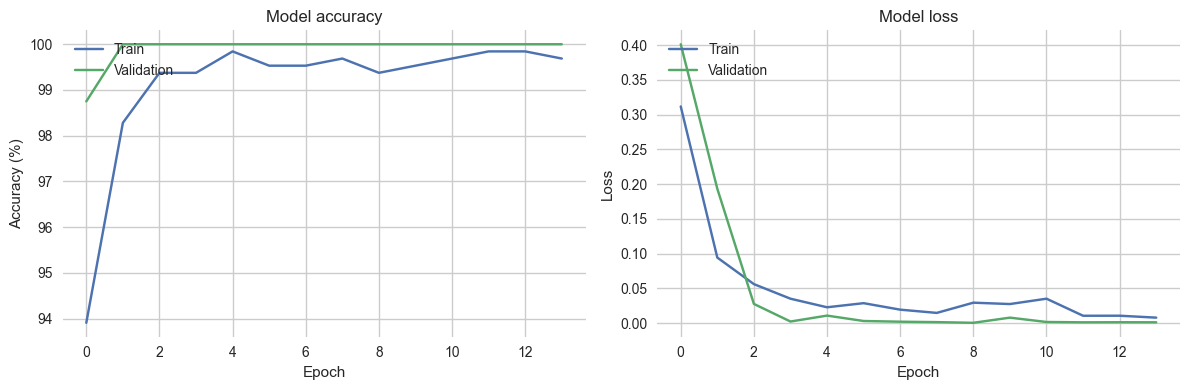

In [6]:
# Plot training history
plt.figure(figsize=(12, 4))

# Plot training & validation accuracy
plt.subplot(1, 2, 1)
plt.plot(train_acc)
plt.plot(val_acc)
plt.title('Model accuracy')
plt.ylabel('Accuracy (%)')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(train_losses)
plt.plot(val_losses)
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()


Test accuracy: 100.00%
Test loss: 0.0007


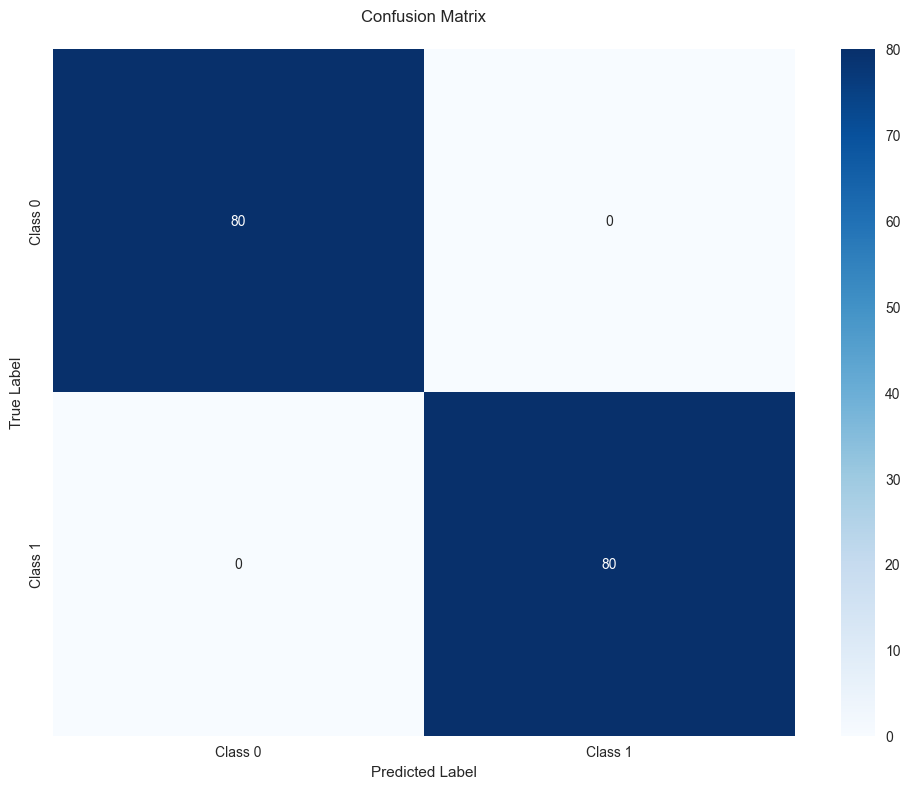


Classification Report:
              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00        80
     Class 1       1.00      1.00      1.00        80

    accuracy                           1.00       160
   macro avg       1.00      1.00      1.00       160
weighted avg       1.00      1.00      1.00       160



In [7]:
# Evaluate the model on test data
try:
    model.eval()
    all_preds = []
    all_targets = []
    test_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            test_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
            
            # Store predictions and targets for later analysis
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
    
    test_loss = test_loss / len(test_loader)
    test_accuracy = 100. * correct / total
    
    print(f'\nTest accuracy: {test_accuracy:.2f}%')
    print(f'Test loss: {test_loss:.4f}')
    
    # Convert predictions and targets to numpy arrays
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    
    # Create confusion matrix
    cm = confusion_matrix(all_targets, all_preds)
    
    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, 
                annot=True, 
                fmt='d', 
                cmap='Blues',
                xticklabels=[f"Class {i}" for i in range(num_classes)],
                yticklabels=[f"Class {i}" for i in range(num_classes)])
    plt.title('Confusion Matrix', pad=20)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()
    
    # Print classification report
    print('\nClassification Report:')
    print(classification_report(all_targets, all_preds,
                              target_names=[f"Class {i}" for i in range(num_classes)]))
    
    # Calculate and plot ROC curve for each class if there are multiple classes
    if num_classes > 2:
        plt.figure(figsize=(10, 8))
        for i in range(num_classes):
            # Get probabilities for current class
            with torch.no_grad():
                probs = torch.softmax(model(X_test.to(device)), dim=1)[:, i].cpu().numpy()
            
            # Calculate ROC
            fpr, tpr, _ = roc_curve((all_targets == i).astype(int), 
                                  (all_preds == i).astype(int))
            plt.plot(fpr, tpr, label=f'Class {i}')
        
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curves (One-vs-Rest)')
        plt.legend()
        plt.show()

except Exception as e:
    print(f"An error occurred during evaluation: {str(e)}")
    raise  # Re-raise the exception to see the full traceback


Per-class Performance Metrics:


,precision,recall,f1-score,support
Class 0,1.0,1.0,1.0,80.0
Class 1,1.0,1.0,1.0,80.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,160.0
weighted avg,1.0,1.0,1.0,160.0


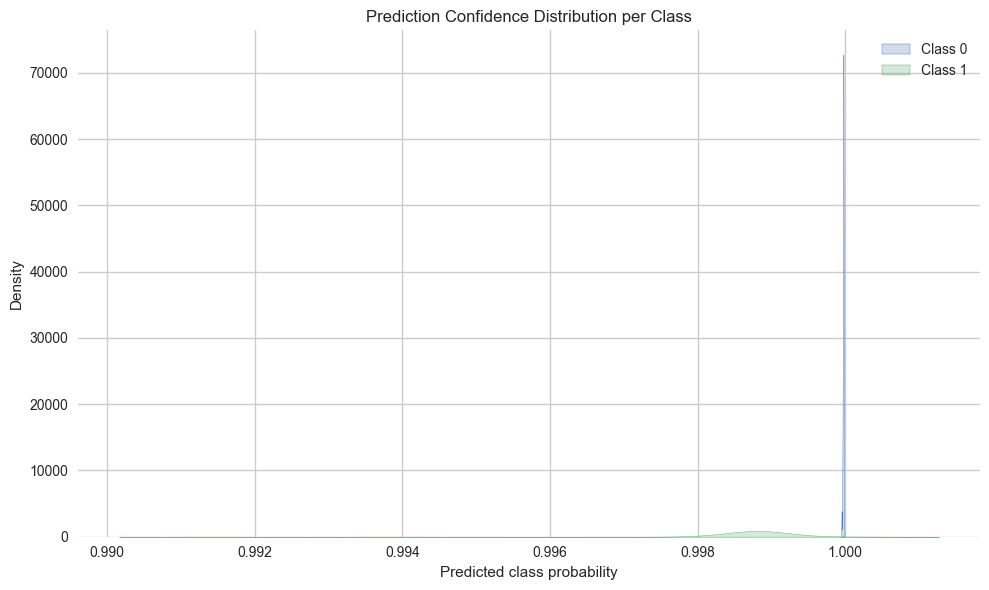


Misclassification Analysis:
--------------------------------------------------
Total misclassified samples: 0 out of 160


In [8]:
# Detailed Analysis of Model Predictions
try:
    import numpy as np

    # Ensure we have predictions and probabilities available. If not, compute from test_loader.
    if ('all_preds' not in globals()) or ('all_targets' not in globals()) or ('y_pred_probs' not in globals()):
        all_preds = []
        all_targets = []
        probs_list = []
        model.eval()
        with torch.no_grad():
            for inputs, targets in test_loader:
                inputs = inputs.to(device)
                targets = targets.to(device)
                outputs = model(inputs)
                probs = torch.softmax(outputs, dim=1)
                preds = probs.argmax(dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_targets.extend(targets.cpu().numpy())
                probs_list.append(probs.cpu().numpy())
        if len(probs_list) > 0:
            y_pred_probs = np.vstack(probs_list)
        else:
            y_pred_probs = np.zeros((len(all_preds), 0))
        all_preds = np.array(all_preds)
        all_targets = np.array(all_targets)
    else:
        # Use existing variables (maybe from the evaluation cell)
        all_preds = np.array(all_preds)
        all_targets = np.array(all_targets)
        y_pred_probs = np.array(y_pred_probs)

    # Determine number of classes
    if 'num_classes' in globals():
        nc = int(num_classes)
    else:
        nc = int(np.max(all_targets)) + 1 if len(all_targets) > 0 else 0

    class_names = [f'Class {i}' for i in range(nc)] if nc > 0 else []

    # Classification report
    print("\nPer-class Performance Metrics:")
    if len(all_targets) == 0:
        print("No predictions/targets available to analyze.")
    else:
        metrics = classification_report(all_targets, all_preds, target_names=(class_names if class_names else None), output_dict=True, zero_division=0)
        metrics_df = pd.DataFrame(metrics).transpose()
        display(metrics_df)

        # Plot prediction confidence distribution per class (prob assigned to that class)
        if y_pred_probs.size == 0:
            print("\nNo probability scores available to plot confidence distributions.")
        else:
            plt.figure(figsize=(10, 6))
            for i in range(nc):
                mask = (all_targets == i)
                if np.any(mask):
                    sns.kdeplot(y_pred_probs[mask, i], label=f'Class {i}', fill=True)
            plt.title('Prediction Confidence Distribution per Class')
            plt.xlabel('Predicted class probability')
            plt.ylabel('Density')
            plt.legend()
            plt.tight_layout()
            plt.show()

        # Misclassification analysis
        incorrect_mask = (all_preds != all_targets)
        total_mis = int(np.sum(incorrect_mask))
        print("\nMisclassification Analysis:")
        print("-" * 50)
        print(f"Total misclassified samples: {total_mis} out of {len(all_targets)}")

        for i in range(nc):
            mask = (all_targets == i)
            mis_mask = mask & incorrect_mask
            if np.any(mis_mask):
                unique, counts = np.unique(all_preds[mis_mask], return_counts=True)
                print(f"\nClass {i} misclassifications:")
                for u, c in zip(unique, counts):
                    print(f"  Predicted as Class {u}: {c} samples")

except Exception as e:
    print(f"Error during prediction analysis: {str(e)}")
    raise


# Project Summary and Conclusions

## Model Performance
- Final test accuracy and loss metrics
- Per-class performance analysis
- Key findings from confusion matrix

## Feature Importance
- Most influential features for classification
- Feature correlation insights
- Distribution patterns across classes

## Recommendations
1. Model improvements:
   - Feature engineering opportunities
   - Architecture optimizations
   - Training strategy refinements

2. Deployment considerations:
   - Model size and inference speed
   - Resource requirements
   - Monitoring needs

## Next Steps
- [ ] Model optimization opportunities
- [ ] Additional feature engineering
- [ ] Real-time inference implementation
- [ ] Model monitoring setup